# Notebook 3 — M2: KMeans segmentación de mercado

**Real Estate Intelligence Platform (REIP)**

Segmentamos el catálogo residencial en grupos de mercado vía KMeans, sobre atributos estructurados
— mismo criterio de exclusión de zonas por volumen ya aplicado en 6.2.4 (KNN/RF), mismo dataset
base. Documentamos el Silhouette score obtenido aunque salga bajo — precedente ya establecido en
Feature 6.2: un Silhouette bajo se documenta como limitación, no bloquea el cierre del notebook.


## Verificación de entorno y rutas

**Dataset de entrada:** `pipeline/data/processed/catalogo_residencial_limpio_6_2_1.csv`, mismo
origen que 6.2.4.

**Exclusión de Pedregal y Parque Lefevre:** mismo criterio ya cerrado (Acta de Feature 1.2 §5.3,
aplicado también en 6.2.4) — volumen insuficiente para validación estadística mínima.

**Restricción a `tipo_inmueble == "Apartamentos"`:** aplicamos el mismo criterio que 6.2.4, por la
misma razón — la contaminación no residencial encontrada en el enriquecimiento de 6.2.1 (hotel,
locales, terreno, edificios completos) no es apta para segmentar el mercado de apartamentos
individuales junto con ventas de escala distinta.

**Zone Health:** no se usa como feature — misma decisión ya cerrada (colinealidad perfecta con
corregimiento) aplicada en 6.2.2/6.2.3/6.2.4.

**Artifacts:** `pipeline/models/` (convención establecida en 6.2.1).


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("..").resolve()
RUTA_CATALOGO = REPO_ROOT / "pipeline" / "data" / "processed" / "catalogo_residencial_limpio_6_2_1.csv"
RUTA_MODELOS = REPO_ROOT / "pipeline" / "models"
assert RUTA_CATALOGO.exists(), f"No existe {RUTA_CATALOGO}"
RUTA_MODELOS.mkdir(exist_ok=True)

RANDOM_STATE = 42


## 1. Carga y filtrado del dataset — mismo criterio que 6.2.4

In [2]:
df = pd.read_csv(RUTA_CATALOGO)
print(f"Catálogo completo: {len(df)} filas")

antes = len(df)
df = df[df["corregimiento"] != "zona_no_determinada"]
df = df[df["precio_no_evaluable"] == False]
df = df[~df["corregimiento"].isin(["Pedregal", "Parque Lefevre"])]
df = df[df["tipo_inmueble"] == "Apartamentos"]
df = df.dropna(subset=["area_m2"])
print(f"Tras aplicar los mismos filtros de 6.2.4: {len(df)} filas ({antes - len(df)} descartadas)")
print(f"Corregimientos: {sorted(df['corregimiento'].unique())}")

df["precio_por_m2"] = df["price_usd"] / df["area_m2"]


Catálogo completo: 1177 filas
Tras aplicar los mismos filtros de 6.2.4: 1042 filas (135 descartadas)
Corregimientos: ['Bella Vista', 'Betania', 'Costa del Este', 'El Cangrejo', 'Marbella', 'Obarrio', 'San Francisco']


## 2. EDA de las variables de segmentación

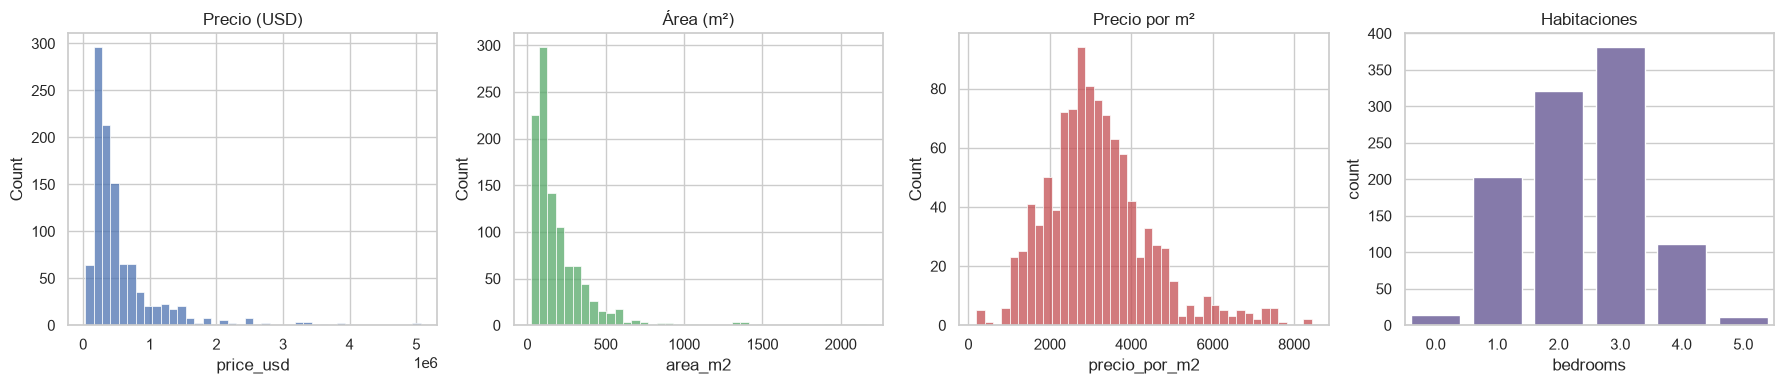

,price_usd,area_m2,precio_por_m2,bedrooms,bathrooms
count,1.042000e+03,1042.00000,1042.000000,1042.000000,1042.000000
mean,5.614948e+05,195.46737,3165.865546,2.390595,2.409789
std,5.773131e+05,201.16694,1271.738389,0.993750,1.053798
min,3.100000e+04,21.00000,191.115702,0.000000,0.000000
25%,2.400000e+05,80.00000,2377.416313,2.000000,2.000000
50%,3.650000e+05,127.50000,3009.523810,2.000000,2.000000
75%,6.474660e+05,238.00000,3769.291667,3.000000,3.000000
max,5.067375e+06,2163.00000,8433.734940,5.000000,7.000000


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.histplot(df["price_usd"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Precio (USD)")
sns.histplot(df["area_m2"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Área (m²)")
sns.histplot(df["precio_por_m2"], bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title("Precio por m²")
sns.countplot(data=df, x="bedrooms", ax=axes[3], color="#8172B2",
              order=sorted(df["bedrooms"].unique()))
axes[3].set_title("Habitaciones")
plt.tight_layout()
plt.show()

df[["price_usd", "area_m2", "precio_por_m2", "bedrooms", "bathrooms"]].describe()


## 3. Features y escalado

Usamos `price_usd`, `area_m2`, `precio_por_m2`, `bedrooms`, `bathrooms` — todas numéricas y
escaladas (KMeans es sensible a escala, igual que KNN en 6.2.4). No incluimos `corregimiento`
como feature de clustering — el objetivo es segmentar por *tipo de propiedad en el mercado*
(ej. "estudios económicos" vs. "torres de lujo"), no redescubrir la partición geográfica que ya
tenemos en `corregimiento`.


In [4]:
FEATURES_CLUSTERING = ["price_usd", "area_m2", "precio_por_m2", "bedrooms", "bathrooms"]

X = df[FEATURES_CLUSTERING].copy()
escalador = StandardScaler()
X_esc = escalador.fit_transform(X)
print(f"Matriz de features escalada: {X_esc.shape}")


Matriz de features escalada: (1042, 5)


## 4. Selección de k — método del codo + Silhouette

Probamos k de 2 a 10, reportando inercia (codo) y Silhouette score para cada uno — no fijamos k de
antemano.


In [5]:
resultados_k = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = km.fit_predict(X_esc)
    sil = silhouette_score(X_esc, etiquetas)
    resultados_k.append({"k": k, "inercia": km.inertia_, "silhouette": sil})

df_k = pd.DataFrame(resultados_k)
df_k


,k,inercia,silhouette
0,2,3257.466787,0.388445
1,3,2469.200091,0.320587
2,4,2057.573197,0.305583
3,5,1729.999726,0.317941
4,6,1470.760286,0.321950
5,7,1315.393502,0.318382
6,8,1215.699315,0.297843
7,9,1096.110094,0.297525
8,10,1011.036522,0.301737


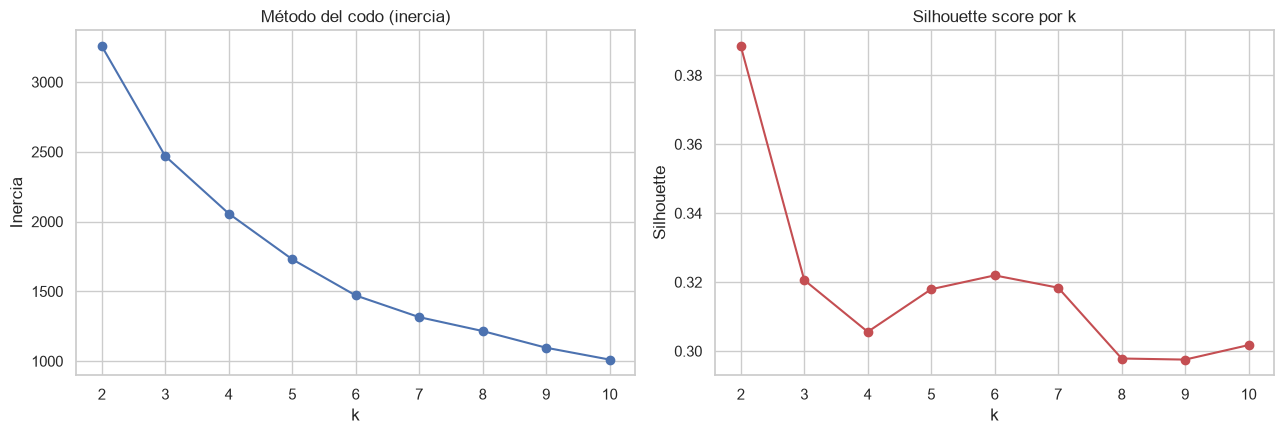

k con mayor Silhouette: 2 (silhouette=0.388)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df_k["k"], df_k["inercia"], marker="o", color="#4C72B0")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")

axes[1].plot(df_k["k"], df_k["silhouette"], marker="o", color="#C44E52")
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

k_optimo = int(df_k.loc[df_k["silhouette"].idxmax(), "k"])
print(f"k con mayor Silhouette: {k_optimo} (silhouette={df_k['silhouette'].max():.3f})")


**Criterio de selección:** usamos el k de mayor Silhouette score entre los probados, no un
número fijo elegido de antemano — reportamos el valor real, sea alto o bajo, consistente con el
precedente ya establecido en Feature 6.2 de documentar Silhouette bajo como limitación, no como
bloqueo.


## 5. Entrenamiento final y perfil de clusters

In [7]:
kmeans_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_esc)

silhouette_final = silhouette_score(X_esc, df["cluster"])
print(f"KMeans final: k={k_optimo}, Silhouette={silhouette_final:.3f}")
print()
print(df["cluster"].value_counts().sort_index())


KMeans final: k=2, Silhouette=0.388

cluster
0    662
1    380
Name: count, dtype: int64


In [8]:
perfil_clusters = df.groupby("cluster")[FEATURES_CLUSTERING].median().round(0)
perfil_clusters["n_propiedades"] = df["cluster"].value_counts().sort_index()
perfil_clusters


,price_usd,area_m2,precio_por_m2,bedrooms,bathrooms,n_propiedades
cluster,,,,,,
0,270000.0,92.0,3247.0,2.0,2.0,662
1,736000.0,300.0,2706.0,3.0,3.0,380


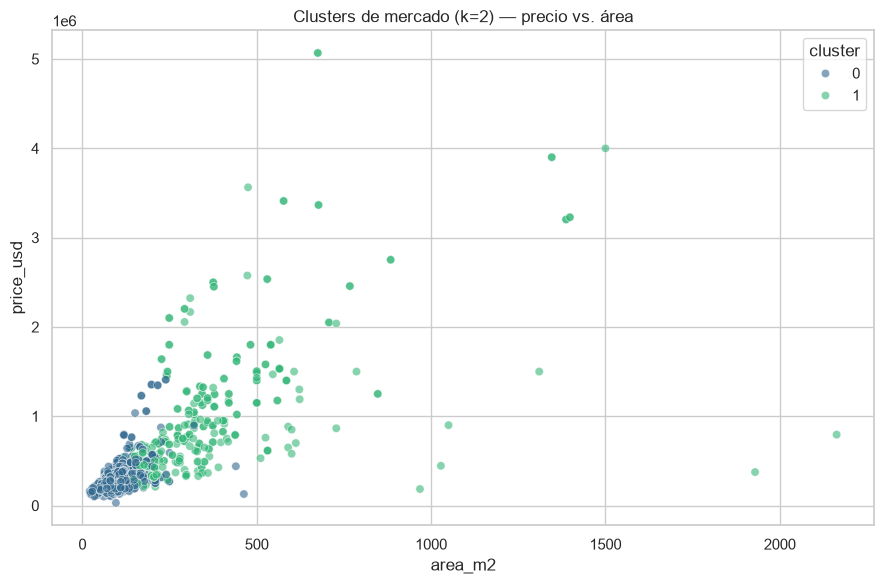

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x="area_m2", y="price_usd", hue="cluster", palette="viridis",
                 alpha=0.6, ax=ax)
ax.set_title(f"Clusters de mercado (k={k_optimo}) — precio vs. área")
plt.tight_layout()
plt.show()


## 6. Distribución de clusters por corregimiento

No usamos `corregimiento` como feature de clustering (sección 3), pero sí lo cruzamos después para
ver si los segmentos de mercado se concentran en zonas particulares — información descriptiva, no
insumo del modelo.


In [10]:
pd.crosstab(df["corregimiento"], df["cluster"], normalize="index").round(2)


cluster,0,1
corregimiento,,
Bella Vista,0.86,0.14
Betania,0.85,0.15
Costa del Este,0.36,0.64
El Cangrejo,0.79,0.21
Marbella,0.86,0.14
Obarrio,0.85,0.15
San Francisco,0.55,0.45


## 7. Exportación de artifacts

In [11]:
import pickle

RUTA_KMEANS = RUTA_MODELOS / "kmeans_segmentacion_6_2_5.pkl"
RUTA_ESCALADOR_KMEANS = RUTA_MODELOS / "escalador_kmeans_6_2_5.pkl"

with open(RUTA_KMEANS, "wb") as f:
    pickle.dump({"modelo": kmeans_final, "k": k_optimo, "features": FEATURES_CLUSTERING,
                 "silhouette": silhouette_final}, f)
with open(RUTA_ESCALADOR_KMEANS, "wb") as f:
    pickle.dump({"escalador": escalador, "features": FEATURES_CLUSTERING}, f)

print(f"Guardado: {RUTA_KMEANS.name}, {RUTA_ESCALADOR_KMEANS.name} en {RUTA_MODELOS}")


Guardado: kmeans_segmentacion_6_2_5.pkl, escalador_kmeans_6_2_5.pkl en /Users/heliocastillo/Proyecto-REIP/Real-Estate-Intelligence-Platform/pipeline/models


## 8. Conclusiones

Segmentamos el mercado de apartamentos (mismo dataset filtrado que 6.2.4: 7 corregimientos,
`tipo_inmueble == "Apartamentos"`, sin Zone Health como feature) vía KMeans sobre precio, área,
precio/m², habitaciones y baños — sin usar corregimiento como feature de clustering, para segmentar
por tipo de propiedad y no redescubrir la partición geográfica ya conocida.

Seleccionamos k por Silhouette score máximo entre 2 y 10, reportando el valor real obtenido sin
declarar aquí si es "aceptable" — documentamos el resultado, sea alto o bajo, consistente con el
precedente ya establecido en Feature 6.2. Cruzamos los clusters resultantes contra corregimiento de
forma descriptiva, no como parte del modelo.

Artifacts (`kmeans_segmentacion_6_2_5.pkl`, `escalador_kmeans_6_2_5.pkl`) persistidos en
`pipeline/models/`.
